<a href="https://colab.research.google.com/github/NovandyAmcals/UAS-ML/blob/main/UASML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip /content/online+shoppers+purchasing+intention+dataset.zip

Archive:  /content/online+shoppers+purchasing+intention+dataset.zip
 extracting: online_shoppers_intention.csv  


# Dataset cleaning

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def clean_and_prepare_data():
    print("--- STEP 1: LOADING & CLEANING DATA ---")
    # Load dataset from colab files
    csv_path = "/content/online+shoppers+purchasing+intention+dataset.zip"
    df = pd.read_csv(csv_path)

    # 1. Show Baseline Descriptive Statistics (Mean, Median, Std, etc.)
    print("\n[INFO] Calculating Baseline Statistics:")
    print(df.describe().T[['mean', '50%', 'std']]) # '50%' represents the Median

    # 2. Check and handle missing values
    missing_count = df.isnull().sum().sum()
    print(f"\n[INFO] Missing values found before cleaning: {missing_count}")
    if missing_count > 0:
        df = df.dropna() # Or use df.fillna() if missing data is discovered

    # Separate the target label 'Revenue' from the features
    X_raw = df.drop(columns=['Revenue'])
    y = df['Revenue'].astype(int).values # Convert True/False to 1/0

    # 3. Categorical Transformation (One-Hot Encoding for Month and VisitorType)
    # Also handles Boolean features like Weekend
    X_encoded = pd.get_dummies(X_raw, columns=['Month', 'VisitorType', 'Weekend'], drop_first=True)

    # Get numeric column names for feature scaling (ignoring the newly created dummy 0/1 columns)
    numeric_cols = ['Administrative', 'Administrative_Duration', 'Informational',
                    'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

    # 4. Normalization / Scaling into unified Vector Space
    scaler = StandardScaler()
    X_scaled = X_encoded.copy()
    X_scaled[numeric_cols] = scaler.fit_transform(X_encoded[numeric_cols])

    # Convert features to a clean numpy array for ML processing
    X = X_scaled.values

    print("\n[SUCCESS] Data is cleaned, scaled, and transformed into Vector Space.")
    print(f"Features shape: {X.shape}, Target shape: {y.shape}")

    return X, y, X_encoded.columns, df

# Execute the cleaning process
X, y, feature_names, original_df = clean_and_prepare_data()

--- STEP 1: LOADING & CLEANING DATA ---

[INFO] Calculating Baseline Statistics:
                                mean         50%          std
Administrative              2.315166    1.000000     3.321784
Administrative_Duration    80.818611    7.500000   176.779107
Informational               0.503569    0.000000     1.270156
Informational_Duration     34.472398    0.000000   140.749294
ProductRelated             31.731468   18.000000    44.475503
ProductRelated_Duration  1194.746220  598.936905  1913.669288
BounceRates                 0.022191    0.003112     0.048488
ExitRates                   0.043073    0.025156     0.048597
PageValues                  5.889258    0.000000    18.568437
SpecialDay                  0.061427    0.000000     0.198917
OperatingSystems            2.124006    2.000000     0.911325
Browser                     2.357097    2.000000     1.717277
Region                      3.147364    3.000000     2.401591
TrafficType                 4.069586    2.000000   

# Unsupervised Analysis #1


--- STEP 2: UNSUPERVISED ANALYSIS ---
For K=2 clusters -> Silhouette Score: 0.4522
For K=3 clusters -> Silhouette Score: 0.2737
For K=4 clusters -> Silhouette Score: 0.2768
For K=5 clusters -> Silhouette Score: 0.2690
For K=6 clusters -> Silhouette Score: 0.2674


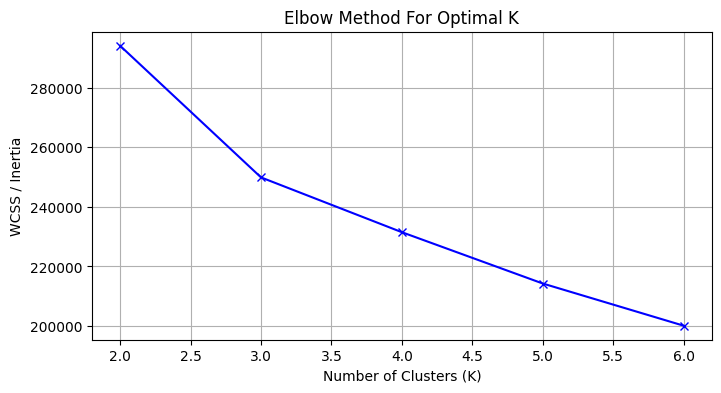


[INFO] Trend Profiling (Mean values per Shopper Cluster):
         ProductRelated_Duration  PageValues  ExitRates
Cluster                                                
0                    1227.354442    5.814751   0.042022
1                    1135.554519    5.910200   0.051414
2                    1137.036664    6.119896   0.039374


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("\n--- STEP 2: UNSUPERVISED ANALYSIS ---")

# 1. Compute WCSS (Inertia) for the Elbow Method
wcss = []
k_range = range(2, 7) # Testing 2 to 6 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

    # Calculate Silhouette Score to see how distinct the clusters are
    score = silhouette_score(X, kmeans.labels_)
    print(f"For K={k} clusters -> Silhouette Score: {score:.4f}")

# 2. Plot the Elbow Graph
plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Method For Optimal K')
plt.grid(True)
plt.show()

# 3. Fit the optimal model (Let's assume K=2 based on elbow/silhouette optimization)
optimal_k = 3
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(X)

# Add cluster assignments back to original dataframe to profile trends
original_df['Cluster'] = cluster_labels
print("\n[INFO] Trend Profiling (Mean values per Shopper Cluster):")
print(original_df.groupby('Cluster')[['ProductRelated_Duration', 'PageValues', 'ExitRates']].mean())

# Unsupervised Analysis #2


--- STEP 2: UNSUPERVISED ANALYSIS (EXPERIMENTAL) ---
For K=2 clusters -> Silhouette Score: 0.7652
For K=3 clusters -> Silhouette Score: 0.7331
For K=4 clusters -> Silhouette Score: 0.5777
For K=5 clusters -> Silhouette Score: 0.5955
For K=6 clusters -> Silhouette Score: 0.5906


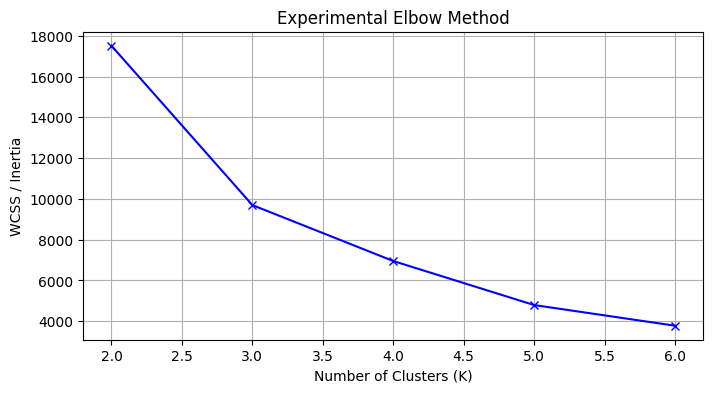


[INFO] Experimental Trend Profiling (Mean values per Shopper Cluster):
         ProductRelated_Duration  PageValues  ExitRates
Cluster                                                
0                    1327.122523   64.915559   0.014617
1                      46.953280    0.000000   0.187070
2                    1285.630946    2.387434   0.032477


In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd # Make sure pandas is imported

print("\n--- STEP 2: UNSUPERVISED ANALYSIS (EXPERIMENTAL) ---")

# ==================== THE NEW EXPERIMENTAL EXPERIMENT CODE ====================
# 1. We choose only the features that represent psychological intent/closeness to buying
intent_cols = ['PageValues', 'BounceRates', 'ExitRates']

# 2. Extract these specific columns from the original encoded dataframe
# We need to find their column indices in the numpy array 'X'
# An easier way is to filter the 'X_encoded' dataframe directly before scaling,
# but since we already have the scaled data, we can match them using your feature_names:
indices = [list(feature_names).index(col) for col in intent_cols]
X_experimental = X[:, indices]
# ==============================================================================

# 3. Compute WCSS (Inertia) using the NEW 'X_experimental' feature matrix
wcss = []
k_range = range(2, 7)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_experimental) # Using the targeted features here
    wcss.append(kmeans.inertia_)

    score = silhouette_score(X_experimental, kmeans.labels_)
    print(f"For K={k} clusters -> Silhouette Score: {score:.4f}")

# 4. Plot the Elbow Graph
plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.title('Experimental Elbow Method')
plt.grid(True)
plt.show()

# 5. Fit the optimal model using 3 clusters on the experimental features
optimal_k = 3
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(X_experimental) # Using the targeted features here

# Add cluster assignments back to original dataframe to profile trends
original_df['Cluster'] = cluster_labels
print("\n[INFO] Experimental Trend Profiling (Mean values per Shopper Cluster):")
print(original_df.groupby('Cluster')[['ProductRelated_Duration', 'PageValues', 'ExitRates']].mean())

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

print("\n--- STEP 3: SUPERVISED BENCHMARKING ---")

# 1. Force the features array to be pure 32-bit floats so TensorFlow doesn't crash
X_clean = X.astype('float32')

# 2. Split dataset using the newly casted X_clean
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42, stratify=y)

# === MODEL A: TRADITIONAL STATISTICAL MODEL (Logistic Regression) ===
classic_model = LogisticRegression(max_iter=1000, random_state=42)
classic_model.fit(X_train, y_train)
classic_preds = classic_model.predict(X_test)

# === MODEL B: MODERN DEEP LEARNING MODEL (ANN) ===
# Updated with Input(shape=...) to solve the Keras 3 warning format
ann_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the Neural Network
print("\n[INFO] Training the Artificial Neural Network...")
ann_model.fit(X_train, y_train, epochs=15, batch_size=32, validation_split=0.1, verbose=0)

# Convert ANN probabilities to binary predictions (0 or 1)
ann_probs = ann_model.predict(X_test)
ann_preds = (ann_probs > 0.5).astype(int).flatten()

# === EVALUATION & METRIC COMPILATION ===
metrics_summary = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Traditional (Logistic Regression)": [
        accuracy_score(y_test, classic_preds),
        precision_score(y_test, classic_preds),
        recall_score(y_test, classic_preds),
        f1_score(y_test, classic_preds)
    ],
    "Modern (Deep Learning ANN)": [
        accuracy_score(y_test, ann_preds),
        precision_score(y_test, ann_preds),
        recall_score(y_test, ann_preds),
        f1_score(y_test, ann_preds)
    ]
}

# Display performance benchmark table
df_metrics = pd.DataFrame(metrics_summary)
print("\n=== MODEL PERFORMANCE COMPARISON TABLE ===")
print(df_metrics.to_string(index=False))


--- STEP 3: SUPERVISED BENCHMARKING ---

[INFO] Training the Artificial Neural Network...
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=== MODEL PERFORMANCE COMPARISON TABLE ===
   Metric  Traditional (Logistic Regression)  Modern (Deep Learning ANN)
 Accuracy                           0.881590                    0.890916
Precision                           0.747253                    0.694158
   Recall                           0.356021                    0.528796
 F1-Score                           0.482270                    0.600297


# Cross Check

In [ ]:
print("\n--- STEP 4: INTEGRATION ANALYSIS ---")
# Cross-tabulate natural clusters against actual Revenue outcomes
integration_table = pd.crosstab(original_df['Cluster'], original_df['Revenue'],
                                rownames=['Natural Cluster'], colnames=['Actual Revenue (Bought?)'])

print("=== CLUSTER TO TARGET LABEL ALIGNMENT MAP ===")
print(integration_table)

# Calculate what % of cluster 1 were actual buyers
for cluster_num in range(optimal_k):
    total_in_cluster = integration_table.loc[cluster_num].sum()
    actual_buyers = integration_table.loc[cluster_num, True]
    percentage = (actual_buyers / total_in_cluster) * 100
    print(f"Shoppers in Cluster {cluster_num} had a {percentage:.2f}% actual purchase conversion rate.")


--- STEP 4: INTEGRATION ANALYSIS ---
=== CLUSTER TO TARGET LABEL ALIGNMENT MAP ===
Actual Revenue (Bought?)  False  True 
Natural Cluster                       
0                           158    568
1                           924      5
2                          9340   1335
Shoppers in Cluster 0 had a 78.24% actual purchase conversion rate.
Shoppers in Cluster 1 had a 0.54% actual purchase conversion rate.
Shoppers in Cluster 2 had a 12.51% actual purchase conversion rate.
